# Gaussian Splatting from scratch
## Drawing splats by hand

A scene of $N$ splats is stored as five tensors, one row per splat:
- `means` (N, 3): center in world coordinates
- `quats` (N, 4): rotation as a quaternion (w, x, y, z), normalized inside gsplat (see below)
- `scales` (N, 3): standard deviation along each local axis, in world units (not log)
- `opacities` (N,): peak opacity in [0, 1] (not a logit)
- `colors` (N, 3): RGB in [0, 1]

### Means

Each splat is a 3D Gaussian centered at $\boldsymbol{\mu} \in \mathbb{R}^3$:

$$
G(\mathbf{x}) = \exp\!\left(-\tfrac{1}{2}(\mathbf{x} - \boldsymbol{\mu})^\top \Sigma^{-1} (\mathbf{x} - \boldsymbol{\mu})\right),
\qquad
\mathbf{x},\, \boldsymbol{\mu} \in \mathbb{R}^{3},\quad
\Sigma \in \mathbb{R}^{3 \times 3},\quad
G(\mathbf{x}) \in (0, 1]
$$

$G$ peaks at $1$ at the center and falls off according to the covariance $\Sigma$.
It is not normalized to integrate to $1$: its height is set by the opacity, not by the volume.

### Quaternion normalization

Only unit quaternions represent pure rotations. gsplat therefore accepts any nonzero
$\mathbf{q} = (w, x, y, z)$ and divides it by its L2 norm before converting it to a rotation matrix:

$$
\hat{\mathbf{q}} = \frac{\mathbf{q}}{\lVert \mathbf{q} \rVert_2},
\qquad
\lVert \mathbf{q} \rVert_2 = \sqrt{w^2 + x^2 + y^2 + z^2}
$$

This lets the optimizer update `quats` freely, with no need to keep them on the unit sphere.
Scaling a quaternion by any positive factor gives the same rotation.

### Scales

An arbitrary $\Sigma$ would not stay positive semi-definite under gradient updates.
Instead, it is built from a rotation $R$ (from $\hat{\mathbf{q}}$) and a scale vector $\mathbf{s} = (s_x, s_y, s_z)$:

$$
\Sigma = R\,S\,S^\top R^\top,
\qquad
S = \operatorname{diag}(s_x, s_y, s_z)
$$

$\Sigma$ is valid by construction. $s_i$ is the standard deviation along the $i$-th local axis before rotation,
so the splat's principal axes are the columns of $R$ with lengths $s_x, s_y, s_z$.

**Example.** $\mathbf{s} = (0.1,\, 0.1,\, 0.01)$ with $R = I$ gives a flat disc in the $xy$-plane,
10 cm wide (one standard deviation) and 1 cm thick.

"Not log": training code usually stores $\log \mathbf{s}$ and passes $\exp(\log \mathbf{s})$ to the rasterizer,
which keeps scales positive. When drawing by hand, pass the scales directly.

### Opacities

After projection to the image, each splat has a 2D covariance $\Sigma'$ and center $\boldsymbol{\mu}'$.
Its alpha at pixel $\mathbf{p}$ is its opacity $o \in [0, 1]$ times the 2D Gaussian falloff:

$$
\alpha(\mathbf{p}) = o \cdot \exp\!\left(-\tfrac{1}{2}(\mathbf{p} - \boldsymbol{\mu}')^\top \Sigma'^{-1} (\mathbf{p} - \boldsymbol{\mu}')\right)
$$

So $o$ is the alpha at the splat's center. gsplat skips contributions with $\alpha < 1/255$.

"Not a logit": training code usually stores $\operatorname{logit}(o)$ and applies a sigmoid,
which keeps $o$ in $(0, 1)$. When drawing by hand, pass $o$ directly.

### Colors

Splats are sorted front to back by depth, and each pixel's color is alpha-composited:

$$
C(\mathbf{p}) = \sum_{i=1}^{N} \mathbf{c}_i\, \alpha_i(\mathbf{p}) \prod_{j=1}^{i-1} \bigl(1 - \alpha_j(\mathbf{p})\bigr)
$$

With `colors` of shape (N, 3) and `sh_degree=None`, $\mathbf{c}_i$ is a fixed RGB value, the same from every viewing direction.
The original 3DGS paper instead stores $K = (L+1)^2$ spherical harmonics coefficients per channel
(shape (N, K, 3), with $L = 3$ so $K = 16$), which makes the color view-dependent.

In [19]:
import os
import shutil

import matplotlib.pyplot as plt
import torch
from scipy.spatial import cKDTree
from torch.utils.data import DataLoader, RandomSampler

from utils.colmap import (
    read_cameras_txt,
    read_images_txt,
    read_points3D_txt,
)
from utils.gs import (
    Splats,
    ViewDataset,
    build_dataset,
    downscale_dataset,
    eval_psnr,
    get_image_paths,
    load_image,
    render,
    save_splats,
)

device = "cuda"

In [2]:
splats = Splats(
    means=torch.tensor([[1.0, 0.0, 0.0], [0.0, 1.0, 0.0], [0.0, 0.0, 10.0]]),
    # quats=torch.tensor([[1.0, 0.0, 0.0, 0.0], [0.924, 0.0, 0.0, 0.383], [1.0, 0.0, 0.0, 0.0]]),
    quats=torch.tensor([[1.0, 0.0, 0.0, 0.0], [1.0, 0.0, 0.0, 0.0], [1.0, 0.0, 0.0, 0.0]]),
    # log_scales=torch.log(torch.tensor([[0.3, 0.3, 0.3], [0.6, 0.1, 0.1], [0.2, 0.5, 0.2]])),
    log_scales=torch.log(torch.tensor([[0.3, 0.3, 0.3], [0.3, 0.3, 0.3], [0.3, 0.3, 0.3]])),
    logit_opacities=torch.logit(torch.tensor([0.9, 0.9, 0.9])),
    colors=torch.tensor([[0.9, 0.2, 0.2], [0.2, 0.8, 0.3], [0.2, 0.4, 0.9]]),
)

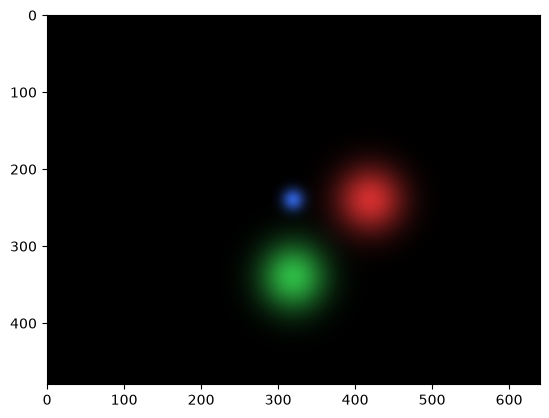

In [3]:
W, H, f = 640, 480, 500.0
K = torch.tensor([[f, 0, W / 2],
                  [0, f, H / 2],
                  [0, 0, 1]])

# World-to-camera: camera at (0, 0, -5) looking along +z.
viewmat = torch.tensor([[1.0, 0.0, 0.0, 0.0],
                             [0.0, 1.0, 0.0, 0.0],
                             [0.0, 0.0, 1.0, 5.0],
                             [0.0, 0.0, 0.0, 1.0]])

img = render(splats.to("cuda"), K.cuda(), viewmat.cuda(), W, H)
img = img.cpu()
plt.imshow(img)
plt.show()

<img src="images/camera_and_world_frames.png" style="width: 1000px;">

## Gaussian Splatting dataset from scratch
First we load the train and test data. We need both the images and their poses + intrinsics.

In [4]:
# Load data.
MODEL = "colmap_results/0_undistorted/sparse_txt"
IMG_FOLDER = "colmap_results/0_undistorted/images"


# 1. cameras.txt stores one camera's intrinsics per line: CAMERA_ID, MODEL, WIDTH, HEIGHT, PARAMS[].
# For the PINHOLE model, PARAMS[] = fx, fy, cx, cy: focal lengths and principal point in pixels.
intrinsics = read_cameras_txt(f"{MODEL}/cameras.txt")
print(f"{len(intrinsics)} camera intrinsics")


# 2. images.txt stores each image over two lines:
#    IMAGE_ID, QW, QX, QY, QZ, TX, TY, TZ, CAMERA_ID, NAME
#    POINTS2D[] as (X, Y, POINT3D_ID)
poses = read_images_txt(f"{MODEL}/images.txt")
print(f"{len(poses)} camera poses")


# 3. points3D.txt stores one triangulated point per line:
#    POINT3D_ID, X, Y, Z, R, G, B, ERROR, TRACK[] as (IMAGE_ID, POINT2D_IDX)
points = read_points3D_txt(f"{MODEL}/points3D.txt")
print(f"{len(points.ids)} points")


# 4. Get dict {filename -> full image path} without loading the image data yet.
image_paths = get_image_paths(IMG_FOLDER)
print(f"{len(image_paths)} image paths")

166 camera intrinsics
166 camera poses
25925 points
166 image paths


### Views

Each view pairs a photo with its camera. `viewmat` maps world points into the camera frame (x right, y down, z forward):

$$
\text{viewmat} =
\begin{bmatrix}
R & \mathbf{t} \\
\mathbf{0}^\top & 1
\end{bmatrix},
\qquad
\mathbf{x}_\text{cam} = R\,\mathbf{x}_\text{world} + \mathbf{t}
$$

<img src="images/viewmat_frames.svg" style="display: block; margin: 100px auto; width: 800px;">

`K` projects camera points to pixels. $f_x, f_y$ are the focal lengths and $(c_x, c_y)$ is the principal point, all in pixels:

$$
K =
\begin{bmatrix}
f_x & 0 & c_x \\
0 & f_y & c_y \\
0 & 0 & 1
\end{bmatrix}
$$

Downscaling an image from $W \times H$ to $W' \times H'$ changes only `K`, since its entries are measured in pixels. With $s_x = W'/W$ and $s_y = H'/H$, horizontal entries scale with $s_x$ and vertical ones with $s_y$:

$$
K' =
\begin{bmatrix}
s_x f_x & 0 & s_x c_x \\
0 & s_y f_y & s_y c_y \\
0 & 0 & 1
\end{bmatrix}
$$

<img src="images/downscaling_intrinsics.svg" style="display: block; margin: 100px auto; width: 900px;">

(Recap of the pinhole camera model)
<img src="images/projection_K.svg" style="display: block; margin: 100px auto; width: 900px;">

In [5]:
# Build a dataset as a list of Views (image_path, K, viewmat)
dataset = build_dataset(image_paths, intrinsics, poses)

In [6]:
# Downscale the dataset if necessary.
DOWNSCALE = 8
OUT_FOLDER = f"colmap_results/0_undistorted/images_{DOWNSCALE}_png"
dataset = downscale_dataset(dataset, OUT_FOLDER, DOWNSCALE)

Downscaling dataset:   0%|          | 0/166 [00:00<?, ?it/s]

In [7]:
print(f"{len(dataset)=}")
dataset[0]

len(dataset)=166


View(image_path='colmap_results/0_undistorted/images_8_png/00126.png', K=tensor([[1.3484e+03, 0.0000e+00, 4.8250e+02],
        [0.0000e+00, 1.3473e+03, 3.2750e+02],
        [0.0000e+00, 0.0000e+00, 1.0000e+00]]), viewmat=tensor([[-0.3813, -0.8256,  0.4159,  0.8148],
        [ 0.7177,  0.0192,  0.6961, -1.1280],
        [-0.5827,  0.5639,  0.5852,  0.7218],
        [ 0.0000,  0.0000,  0.0000,  1.0000]]))

In [8]:
# Split train and val. Every TEST_EVERY image becomes a test image.
TEST_EVERY = 8

train_set = [im for i, im in enumerate(dataset) if i % TEST_EVERY != 0]
val_set = [im for i, im in enumerate(dataset) if i % TEST_EVERY == 0]

print(f"{len(train_set)=}")
print(f"{len(val_set)=}")

len(train_set)=145
len(val_set)=21


In [9]:
train_set[0]

View(image_path='colmap_results/0_undistorted/images_8_png/00125.png', K=tensor([[1.2622e+03, 0.0000e+00, 4.8200e+02],
        [0.0000e+00, 1.2622e+03, 3.2700e+02],
        [0.0000e+00, 0.0000e+00, 1.0000e+00]]), viewmat=tensor([[-0.4335, -0.7731,  0.4630,  0.7111],
        [ 0.7418, -0.0144,  0.6705, -1.1188],
        [-0.5117,  0.6341,  0.5797,  1.3288],
        [ 0.0000,  0.0000,  0.0000,  1.0000]]))

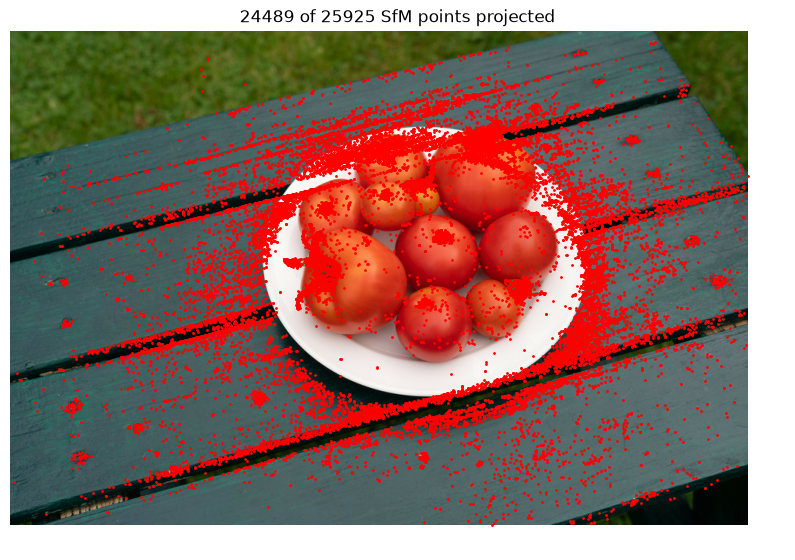

In [10]:
# Sanity check.
view = train_set[2]
img = load_image(view).cpu()
H, W = img.shape[:2]

# World -> camera: x_cam = R @ x_world + t, as one 4x4 multiply on homogeneous points
xyz = torch.from_numpy(points.xyz).float()               # (P, 3)
xyz_h = torch.cat([xyz, torch.ones(len(xyz), 1)], dim=1)  # (P, 4)
cam = (view.viewmat @ xyz_h.T).T[:, :3]
cam = cam[cam[:, 2] > 0]  # keep points in front of the camera

# Camera -> pixels: multiply by K, then divide by depth
uv = (view.K @ cam.T).T
uv = uv[:, :2] / uv[:, 2:]
inside = (uv[:, 0] >= 0) & (uv[:, 0] < W) & (uv[:, 1] >= 0) & (uv[:, 1] < H)

plt.figure(figsize=(10, 7))
plt.imshow(img)
plt.scatter(uv[inside, 0], uv[inside, 1], s=1, c="red")
plt.title(f"{inside.sum()} of {len(xyz)} SfM points projected")
plt.axis("off")
plt.show()

## Gaussian Splatting training from scratch

In [ ]:
RESULTS_DIR = "gs_from_scratch_results"

shutil.rmtree(RESULTS_DIR, ignore_errors=True)
os.makedirs(RESULTS_DIR)

In [11]:
# Set up data loader.
N_STEPS = 10000
train_data = ViewDataset(train_set)

loader = DataLoader(
    train_data,
    batch_size=None,
    sampler=RandomSampler(train_data, num_samples=N_STEPS),  # STEPS indices, one shuffled pass after another
    num_workers=4,
    pin_memory=True,
)

In [12]:
batch = next(iter(loader))

for elem in batch:
    print(elem.shape, elem.dtype)

torch.Size([634, 965, 3]) torch.uint8
torch.Size([3, 3]) torch.float32
torch.Size([4, 4]) torch.float32


### Initialize splats

Each SfM point becomes one splat. Its initial scale is the RMS distance to its 3 nearest neighbors, the same on all three axes (a sphere):

$$
\mathbf{s}_i = (\bar{d}_i,\, \bar{d}_i,\, \bar{d}_i),
\qquad
\bar{d}_i = \sqrt{\tfrac{1}{3}\left(d_{i1}^2 + d_{i2}^2 + d_{i3}^2\right)}
$$

<img src="images/knn_init.svg" style="display: block; margin: 100px auto; width: 1200px;">

Neighboring splats must overlap. Too small leaves holes, which get no gradient to close them; too large blurs everything. $\bar{d}_i$ adapts to the local density: small splats where SfM points are dense (detail), large ones where they are sparse (coverage). The RMS leans toward the farthest neighbor, so it errs on the side of overlap.

In [13]:
# Positions and colors straight from COLMAP's points3D.txt
xyz = torch.from_numpy(points.xyz).float()          # (N, 3)
rgb = torch.from_numpy(points.rgb / 255.0).float()  # (N, 3) in [0, 1]
N_SPLATS = len(xyz)

# Size: RMS distance to the 3 nearest neighbors for every point (k=4, because the nearest hit is the point itself)
dists, _ = cKDTree(xyz.numpy()).query(xyz.numpy(), k=4)                    # (N, 4)
dist_avg = torch.from_numpy(dists[:, 1:] ** 2).float().mean(dim=1).sqrt()  # (N,)

splats = Splats(
    means=xyz,
    quats=torch.rand(N_SPLATS, 4),                                    # random rotation (rasterization normalizes it)
    log_scales=dist_avg.clamp_min(1e-7).log()[:, None].repeat(1, 3),  # same size on all 3 axes: a sphere
    logit_opacities=torch.logit(torch.full((N_SPLATS,), 0.1)),
    colors=rgb,
)
splats = splats.to(device).requires_grad_()
print(f"{N_SPLATS} splats")

25925 splats


### Optimizer and scene scale

COLMAP's world unit is arbitrary: photos carry no absolute scale. Adam moves a parameter by roughly `lr` per step, so the means need a learning rate in scene units. The scene size is the radius of the camera rig, with camera centers $\mathbf{C}_i = -R_i^\top \mathbf{t}_i$:

$$
\text{scene\_scale} = 1.1 \cdot \max_i \lVert \mathbf{C}_i - \bar{\mathbf{C}} \rVert,
\qquad
\text{lr}_\text{means} = 1.6 \cdot 10^{-4} \cdot \text{scene\_scale}
$$

<img src="images/scene_scale.svg" style="display: block; margin: 24px auto; width: 900px;">

Each step then moves a splat by the same fraction of the scene, whatever the unit. The other parameters have no world unit (rotations, log scales, logit opacities, colors), so their learning rates are constants. `eps=1e-15` keeps Adam's steps at `lr` even for the tiny gradients of individual splats.

In [14]:
# Set up optimizer.
# gsplat: scene_scale = 1.1 * max distance of a camera center from the mean camera center
centers = torch.stack([-v.viewmat[:3, :3].T @ v.viewmat[:3, 3] for v in train_set])
scene_scale = 1.1 * (centers - centers.mean(0)).norm(dim=1).max().item()

optimizer = torch.optim.Adam([
    {"params": [splats.means],           "lr": 1.6e-4 * scene_scale},
    {"params": [splats.quats],           "lr": 1e-3},
    {"params": [splats.log_scales],      "lr": 5e-3},
    {"params": [splats.logit_opacities], "lr": 5e-2},
    {"params": [splats.colors],          "lr": 2.5e-3},
], eps=1e-15)

In [ ]:
for step, (img, K, viewmat) in enumerate(loader):
    # 1. Get the next photo and its camera, and move them to the GPU.
    gt = img.to(device, non_blocking=True).float() / 255
    K, viewmat = K.to(device), viewmat.to(device)
    H, W = gt.shape[:2]

    # 2. Render the splats from that camera and compare with the photo.
    pred = render(splats, K, viewmat, W, H)
    loss = (pred - gt).abs().mean()  # L1: mean absolute pixel difference

    # 3. Backpropagate through the rasterizer and update every splat parameter.
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # 4. Every x steps: report the loss and save a checkpoint.
    if step % 1000 == 0:
        print(f"step {step:6d}  L1 {loss.item():.4f}  PSNR {eval_psnr(splats, val_set):.2f}")
        save_splats(splats, , f"splats_{step}.pt")
        
        
# Save final state.
save_splats(splats, "gs_from_scratch_results", f"splats_{step + 1}.pt")

step      0  L1 0.0694  PSNR 23.08
step    500  L1 0.0357  PSNR 23.23
step   1000  L1 0.0404  PSNR 23.72
step   1500  L1 0.0360  PSNR 23.74
step   2000  L1 0.0341  PSNR 23.93
step   2500  L1 0.0352  PSNR 23.98
step   3000  L1 0.0310  PSNR 24.11
step   3500  L1 0.0435  PSNR 24.16
step   4000  L1 0.0548  PSNR 24.23
step   4500  L1 0.0362  PSNR 24.35
step   5000  L1 0.0344  PSNR 24.50
step   5500  L1 0.0265  PSNR 24.45
step   6000  L1 0.0330  PSNR 24.58
step   6500  L1 0.0326  PSNR 24.69
step   7000  L1 0.0547  PSNR 24.68
step   7500  L1 0.0387  PSNR 24.64
step   8000  L1 0.0317  PSNR 24.74
step   8500  L1 0.0432  PSNR 24.94
step   9000  L1 0.0715  PSNR 24.96
step   9500  L1 0.0347  PSNR 24.94


'gs_from_scratch_results/splats_10000.pt'

## Validation

len(val_set)=21


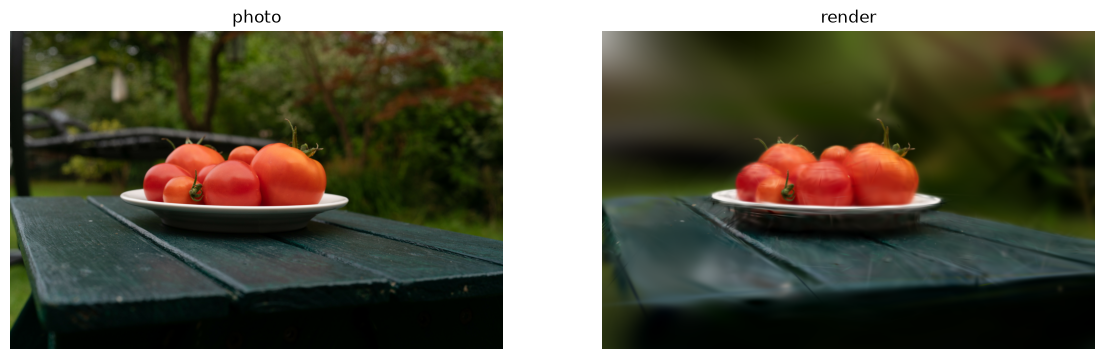

In [17]:
# Plot a view from the val set.
print(f"{len(val_set)=}")
view = val_set[2]

with torch.no_grad():
    gt = load_image(view)
    pred = render(splats, view.K.to(device), view.viewmat.to(device), gt.shape[1], gt.shape[0])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, im, title in zip(axes, [gt, pred], ["photo", "render"]):
    ax.imshow(im.clamp(0, 1).cpu())
    ax.set_title(title)
    ax.axis("off")
plt.show()

In [18]:
!cd /home/boldi/Apps/gsplat/examples && \
python simple_viewer.py \
    --ckpt "/home/boldi/code/MA/gs-intro/gs_from_scratch_results/splats_{N_STEPS}.pt" \
    --port 8080

Number of Gaussians: 25925
╭────── viser (listening *:8080) ───────╮
│             ╷                         │
│   HTTP      │ http://localhost:8080   │
│   Websocket │ ws://localhost:8080     │
│             ╵                         │
╰───────────────────────────────────────╯
Viewer running... Ctrl+C to exit.
Traceback (most recent call last):
  File "/home/boldi/Apps/gsplat/examples/simple_viewer.py", line 366, in <module>
    cli(main, args, verbose=True)
  File "/home/boldi/Apps/gsplat/examples/../gsplat/distributed.py", line 375, in cli
    return _distributed_worker(0, 1, fn=fn, args=args)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/boldi/Apps/gsplat/examples/../gsplat/distributed.py", line 310, in _distributed_worker
    fn(local_rank, world_rank, world_size, args)
  File "/home/boldi/Apps/gsplat/examples/simple_viewer.py", line 325, in main
    time.sleep(100000)
KeyboardInterrupt
connection handler failed
Traceback (most recent call last):
  File "/ho